# Fundamentos de Machine Learning
## Métodos de Validación: Train/Test Split vs Cross-Validation

---

**Inteligencia Artificial: De los Fundamentos a la Implementación**

Temas:
- Cómo preparar datos para Machine Learning
- La diferencia entre **Train/Test Split** y **Cross-Validation**
- Cuándo usar cada método y sus ventajas/desventajas
- Implementación práctica con un dataset real de ventas

---
## Parte 1: Conceptos Teóricos

### ¿Por qué necesitamos validar modelos?

Cuando entrenamos un modelo de Machine Learning, queremos que **generalice bien** a datos nuevos que nunca ha visto. El problema es:

- Si evaluamos el modelo con los mismos datos que usamos para entrenarlo, obtenemos una estimación **optimista** (overfitting)
- Necesitamos una forma de estimar cómo se comportará con datos nuevos

### Método 1: Train/Test Split (División simple)

```
Dataset completo (100%)
├── Train (80%) → Entrenar el modelo
└── Test (20%)  → Evaluar el modelo
```

**Ventajas:**
- Simple y rápido
- Fácil de entender e implementar

**Desventajas:**
- El resultado depende de qué datos caen en cada conjunto
- "Desperdiciamos" el 20% de los datos para evaluación
- Alta varianza en la estimación del rendimiento

### Método 2: K-Fold Cross-Validation

```
Dataset dividido en 5 partes (K=5)

Fold 1: [TEST] [Train] [Train] [Train] [Train]
Fold 2: [Train] [TEST] [Train] [Train] [Train]
Fold 3: [Train] [Train] [TEST] [Train] [Train]
Fold 4: [Train] [Train] [Train] [TEST] [Train]
Fold 5: [Train] [Train] [Train] [Train] [TEST]

Resultado final = Promedio de los 5 folds
```

**Ventajas:**
- Usa el 100% de los datos para entrenamiento Y evaluación
- Estimación más robusta y estable
- Menor varianza en los resultados

**Desventajas:**
- Más lento (entrena K modelos)
- Más complejo de implementar

---
## Parte 2: Configuración del Entorno

In [3]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
# ============================================================================
# DIVISIÓN Y VALIDACIÓN DE DATOS
# ============================================================================
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# train_test_split: Divide el dataset en conjuntos de entrenamiento y prueba
#                   Ejemplo: X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
#                   Uso: Validación simple, separar datos para evaluar el modelo

# cross_val_score:  Ejecuta Cross-Validation automáticamente y devuelve los scores
#                   Ejemplo: scores = cross_val_score(modelo, X, y, cv=5, scoring='r2')
#                   Uso: Evaluar modelo de forma robusta con una sola línea de código

# KFold:            Genera los índices para dividir datos en K partes (folds)
#                   Ejemplo: kf = KFold(n_splits=5, shuffle=True, random_state=42)
#                   Uso: Control manual del proceso de Cross-Validation

# ============================================================================
# MODELOS DE REGRESIÓN
# ============================================================================
from sklearn.linear_model import LinearRegression, Ridge

# LinearRegression: Regresión lineal clásica (mínimos cuadrados ordinarios)
#                   Encuentra la línea que minimiza el error cuadrático
#                   Uso: Modelo baseline simple, relaciones lineales

# Ridge:            Regresión lineal con regularización L2
#                   Penaliza coeficientes muy grandes para evitar overfitting
#                   Uso: Cuando hay multicolinealidad o muchas features

from sklearn.ensemble import RandomForestRegressor

# RandomForestRegressor: Conjunto de árboles de decisión para regresión
#                        Combina predicciones de múltiples árboles (bagging)
#                        Uso: Modelos robustos, captura relaciones no lineales

# ============================================================================
# PREPROCESAMIENTO DE DATOS
# ============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder

# StandardScaler:   Estandariza features: media=0, desviación estándar=1
#                   Fórmula: z = (x - μ) / σ
#                   Uso: Necesario para algoritmos sensibles a escala (SVM, redes neuronales)

# LabelEncoder:     Convierte categorías de texto a números (0, 1, 2, ...)
#                   Ejemplo: ['Norte', 'Sur', 'Centro'] → [0, 1, 2]
#                   Uso: Preparar variables categóricas para modelos ML

# ============================================================================
# MÉTRICAS DE EVALUACIÓN (REGRESIÓN)
# ============================================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# mean_squared_error (MSE): Promedio del cuadrado de los errores
#                           Penaliza fuertemente errores grandes
#                           RMSE = √MSE (mismas unidades que y)

# mean_absolute_error (MAE): Promedio del valor absoluto de los errores
#                            Más robusto a outliers que MSE
#                            Interpretación directa: "error promedio en unidades"

# r2_score (R²):    Coeficiente de determinación (0 a 1, puede ser negativo)
#                   Qué proporción de la varianza explica el modelo
#                   R² = 1: predicción perfecta | R² = 0: igual que predecir la media

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

ModuleNotFoundError: No module named 'sklearn'

---
## Parte 3: Carga y Exploración del Dataset

In [ ]:
# Cargar el dataset desde archivo local
df = pd.read_csv('ventas.csv')

print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')


In [4]:
# Vista previa de los datos
df.head(10)

,transaccion_id,fecha,categoria,producto,region,ciudad,vendedor,cliente_id,precio,cantidad,costo,monto,descuento,items
0,TRX000001,2023-11-12,Ropa,Sudadera,Norte,Tijuana,V018,C14157,205.57,2,172.68,411.14,3.1,2
1,TRX000002,2022-11-01,Ropa,Vestido,Sur,Villahermosa,V001,C01160,103.62,2,66.60,207.24,10.3,4
2,TRX000003,2024-08-25,Electrónica,Smartphone,Norte,Tijuana,V020,C08766,1924.73,9,1366.69,17322.57,4.0,9
3,TRX000004,2023-06-28,Deportes,Balón,Este,NaN,V032,C10636,184.77,3,120.18,554.31,1.5,4
4,TRX000005,2024-04-10,Deportes,Pesas,Centro,CDMX,V028,C11563,445.9,2,287.46,891.80,0.4,4
5,TRX000006,2022-08-21,Ropa,Zapatos,Sur,Villahermosa,V023,C13765,178.86,8,142.58,1430.88,6.9,10
6,TRX000007,2023-05-01,Hogar,Mesa,Norte,Chihuahua,V013,C05175,324.02,2,225.35,648.04,2.3,3
7,TRX000008,2022-03-27,Electrónica,Tablet,Norte,Saltillo,V008,C01388,1976.46,2,1618.68,3952.92,3.2,2
8,TRX000009,2023-04-11,Hogar,Silla,Norte,Monterrey,V023,C02207,163.89,3,111.62,491.67,0.1,3
9,TRX000010,2024-02-25,Alimentos,Arroz,Sur,Cancún,V016,C00604,30.67,1,24.41,30.67,1.9,3


In [7]:
# Información general del dataset
print('INFORMACIÓN DEL DATASET')
print('=' * 50)
df.info()

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204000 entries, 0 to 203999
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   transaccion_id  204000 non-null  object 
 1   fecha           204000 non-null  object 
 2   categoria       204000 non-null  object 
 3   producto        204000 non-null  object 
 4   region          204000 non-null  object 
 5   ciudad          197179 non-null  object 
 6   vendedor        199795 non-null  object 
 7   cliente_id      204000 non-null  object 
 8   precio          204000 non-null  object 
 9   cantidad        204000 non-null  int64  
 10  costo           199917 non-null  float64
 11  monto           204000 non-null  float64
 12  descuento       199085 non-null  float64
 13  items           204000 non-null  int64  
dtypes: float64(3), int64(2), object(9)
memory usage: 21.8+ MB


In [8]:
# Análisis de valores nulos
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

print('VALORES NULOS POR COLUMNA')
print('=' * 50)
for col in df.columns:
    if nulos[col] > 0:
        print(f'  {col}: {nulos[col]:,} ({nulos_pct[col]}%)')

print(f'\n Total filas con al menos un nulo: {df.isnull().any(axis=1).sum():,}')

VALORES NULOS POR COLUMNA
  ciudad: 6,821 (3.34%)
  vendedor: 4,205 (2.06%)
  costo: 4,083 (2.0%)
  descuento: 4,915 (2.41%)

 Total filas con al menos un nulo: 19,325


In [9]:
# Verificar duplicados
duplicados = df.duplicated(subset=['fecha', 'cliente_id', 'producto', 'monto']).sum()
print(f'Registros duplicados detectados: {duplicados:,}')

Registros duplicados detectados: 3,925


---
## Parte 4: Limpieza de Datos

Antes de entrenar cualquier modelo, debemos limpiar los datos.

In [10]:
# Crear copia para limpieza
df_clean = df.copy()
print(f'Shape inicial: {df_clean.shape}')

Shape inicial: (204000, 14)


In [12]:
# 1. Eliminar duplicados
n_antes = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['fecha', 'cliente_id', 'producto', 'monto'])
print(f'Duplicados eliminados: {n_antes - len(df_clean):,}')

Duplicados eliminados: 0


In [ ]:
# 2. Limpiar columna 'precio' (remover cualquier caracter no numérico)
df_clean['precio'] = df_clean['precio'].astype(str).str.replace('[^0-9.]', '', regex=True)
df_clean['precio'] = pd.to_numeric(df_clean['precio'], errors='coerce')

In [14]:
# 3. Estandarizar columna 'region'
df_clean['region'] = df_clean['region'].str.strip().str.title()
print('Valores únicos en region:', df_clean['region'].unique())

Valores únicos en region: ['Norte' 'Sur' 'Este' 'Centro' 'Oeste']


In [16]:
# 4. Corregir valores negativos en cantidad
negativos = (df_clean['cantidad'] < 0).sum()
df_clean['cantidad'] = df_clean['cantidad'].abs()
print(f'Valores negativos corregidos: {negativos}')

Valores negativos corregidos: 0


In [18]:
# 5. Imputar valores nulos
# Numéricas: mediana
for col in ['precio', 'costo', 'descuento']:
    mediana = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(mediana)

# Categóricas: moda
for col in ['ciudad', 'vendedor']:
    moda = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(moda)

print(f'Nulos restantes: {df_clean.isnull().sum().sum()}')

Nulos restantes: 0


### ¿Qué es imputar?

**Imputar** = Reemplazar valores faltantes (NaN) con un valor calculado.

### Línea por línea:

| Línea | ¿Qué hace? |
|-------|------------|
| `df_clean[col].median()` | Calcula la mediana de la columna (valor del medio) |
| `df_clean[col].fillna(mediana)` | Reemplaza los NaN con ese valor |
| `df_clean[col].mode()[0]` | Calcula la moda (valor más frecuente). El `[0]` toma el primero si hay empate |

### Ejemplo visual - Numéricas (mediana):
```
COLUMNA: precio                      
                                     
ANTES              DESPUÉS           
┌─────────┐        ┌─────────┐       
│  100    │        │  100    │       
│  150    │        │  150    │       
│  NaN    │   →    │  175    │ ← mediana
│  200    │        │  200    │       
│  NaN    │   →    │  175    │ ← mediana
│  250    │        │  250    │       
└─────────┘        └─────────┘       
                                     
Mediana de [100,150,200,250] = 175   
```

### Ejemplo visual - Categóricas (moda):
```
COLUMNA: ciudad                         
                                        
ANTES              DESPUÉS              
┌─────────┐        ┌─────────┐          
│ CDMX    │        │ CDMX    │          
│ CDMX    │        │ CDMX    │          
│ NaN     │   →    │ CDMX    │ ← moda   
│ Puebla  │        │ Puebla  │          
│ NaN     │   →    │ CDMX    │ ← moda   
│ CDMX    │        │ CDMX    │          
└─────────┘        └─────────┘          
                                        
Moda = "CDMX" (aparece 3 veces)         
```

### ¿Por qué mediana y no media?

| Medida | Fórmula | Problema con outliers |
|--------|---------|----------------------|
| **Media** | Suma / N | Sensible a valores extremos |
| **Mediana** | Valor del medio | Robusta a outliers ✓ |
```
Ejemplo: precios = [100, 150, 200, 250, 10000]

Media   = 2140  ← distorsionada por el 10000
Mediana = 200   ← refleja mejor el centro real
```

### ¿Por qué moda para categóricas?

No puedes calcular "promedio" de textos. La moda (valor más frecuente) es la única opción lógica:
```
Media de ["CDMX", "Puebla", "CDMX"] = ???
Moda de ["CDMX", "Puebla", "CDMX"] = "CDMX"

In [20]:
# 6. Eliminar outliers extremos en monto (IQR)
Q1 = df_clean['monto'].quantile(0.25)
Q3 = df_clean['monto'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 3 * IQR  # Usamos 3*IQR para ser menos agresivos

n_antes = len(df_clean)
df_clean = df_clean[df_clean['monto'] <= limite_superior]
print(f' Outliers extremos eliminados: {n_antes - len(df_clean):,}')
print(f'\n Shape final limpio: {df_clean.shape}')

 Outliers extremos eliminados: 2,976

 Shape final limpio: (187187, 14)



### ¿Qué son los cuartiles?
Los cuartiles dividen los datos ordenados en 4 partes iguales:
```
Datos: [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]
             ↑           ↑            ↑
            Q1          Q2           Q3
          (25%)       (50%)        (75%)
                    (mediana)
```

---

### Visualización del método IQR
```
                       IQR (50% central)
                  ┌────────────┐
                  │            │
  ├───────────────┼────────────┼───────────────────────┤
  0              Q1           Q3                    Datos
                $500        $2,000

  │←── 25% ───→│←─── 50% ───→│←────── 25% ────────→│
```

---

### Fórmulas de límites

| Multiplicador | Límite superior | Detecta |
|---------------|-----------------|---------|
| 1.5 × IQR | Q3 + 1.5×IQR | Outliers moderados |
| **3.0 × IQR** | **Q3 + 3.0×IQR** ✓ | **Solo extremos** |

---

### Ejemplo visual
```
ANTES                              DESPUÉS

50,000 │ ●  ← se elimina           
10,000 │ ●  ← se elimina           
 6,500 │────── LÍMITE ──────       6,500 │────── LÍMITE ──────
 5,000 │ ●                         5,000 │ ●
 3,000 │ ●●●                       3,000 │ ●●●
 2,000 │ ●●●●● ← Q3                2,000 │ ●●●●●
 1,000 │ ●●●●●●●                   1,000 │ ●●●●●●●
   500 │ ●●●●● ← Q1                  500 │ ●●●●●
   100 │ ●●                          100 │ ●●
       └──────────                       └──────────
```

---
## Parte 5: Feature Engineering

Creamos variables adicionales que pueden ayudar al modelo.

In [21]:
# Convertir fecha a datetime
def parse_fecha(fecha):
    try:
        if '/' in str(fecha):
            return pd.to_datetime(fecha, format='%d/%m/%Y')
        else:
            return pd.to_datetime(fecha)
    except:
        return pd.NaT

df_clean['fecha'] = df_clean['fecha'].apply(parse_fecha)
df_clean = df_clean.dropna(subset=['fecha'])

In [23]:
# Features temporales
df_clean['año'] = df_clean['fecha'].dt.year
df_clean['mes'] = df_clean['fecha'].dt.month
df_clean['dia_semana'] = df_clean['fecha'].dt.dayofweek
df_clean['es_finde'] = (df_clean['dia_semana'] >= 5).astype(int)
df_clean['trimestre'] = df_clean['fecha'].dt.quarter

print(' Features temporales creadas')

 Features temporales creadas


In [25]:
# Features de ratio
df_clean['margen'] = df_clean['precio'] - df_clean['costo']
df_clean['margen_pct'] = (df_clean['margen'] / df_clean['precio'] * 100).round(2)
df_clean['monto_neto'] = df_clean['monto'] * (1 - df_clean['descuento']/100)

print(' Features de ratio creadas')

 Features de ratio creadas


In [26]:
# Encoding de variables categóricas
le_categoria = LabelEncoder()
le_region = LabelEncoder()

df_clean['categoria_encoded'] = le_categoria.fit_transform(df_clean['categoria'])
df_clean['region_encoded'] = le_region.fit_transform(df_clean['region'])

print(' Variables categóricas codificadas')
print(f'\n Shape final: {df_clean.shape}')

 Variables categóricas codificadas

 Shape final: (187187, 24)


## Encoding de Variables Categóricas

### ¿Por qué codificar?

Los algoritmos de ML solo entienden **números**, no texto:
```
Mal ['Electrónica', 'Ropa', 'Hogar']  → El modelo no puede procesarlo
Bien [2, 4, 3]                         → El modelo sí puede procesarlo
```

---

### ¿Qué hace LabelEncoder?

Asigna un número único a cada categoría (orden alfabético):
```
categoria                    categoria_encoded

Alimentos     ──────────→         0
Deportes      ──────────→         1
Electrónica   ──────────→         2
Hogar         ──────────→         3
Ropa          ──────────→         4
```

---

### ¿Por qué un encoder por columna?

Cada columna tiene sus propias categorías:
```
le_categoria:               le_region:

Alimentos   → 0             Centro → 0
Deportes    → 1             Este   → 1
Electrónica → 2             Norte  → 2
Hogar       → 3             Oeste  → 3
Ropa        → 4             Sur    → 4
```

---

### fit_transform = fit + transform

| Método | ¿Qué hace? |
|--------|------------|
| `fit()` | Aprende qué categorías existen |
| `transform()` | Convierte las categorías a números |
| `fit_transform()` | Hace ambas cosas en un solo paso |

> **Nota:** LabelEncoder asigna números arbitrarios. Para algunos modelos (regresión lineal), es mejor usar **One-Hot Encoding** (`pd.get_dummies()`) para evitar que el modelo interprete orden donde no existe.

---
## Parte 6: Preparación para Machine Learning

**Objetivo:** Predecir el `monto` de venta basado en las características disponibles.

In [28]:
# Definir features (X) y target (y)
feature_cols = [
    'precio', 'cantidad', 'costo', 'descuento', 'items',
    'mes', 'dia_semana', 'es_finde', 'trimestre',
    'categoria_encoded', 'region_encoded', 'margen'
]

X = df_clean[feature_cols].copy() #datos a usar
y = df_clean['monto'].copy() #datos a predecir

# Verificar que no hay nulos
print(f'Features (X): {X.shape}')
print(f'Target (y): {y.shape}')
print(f'Nulos en X: {X.isnull().sum().sum()}')

Features (X): (187187, 12)
Target (y): (187187,)
Nulos en X: 0


## Definir Features (X) y Target (y)

### Concepto clave
```
FEATURES (X)                         TARGET (y)
┌────────────────────────────┐       ┌──────────┐
│ precio, cantidad, costo,   │       │          │
│ descuento, mes, dia_semana │   →   │  monto   │
│ es_finde, trimestre, ...   │       │          │
│                            │       │(predecir)│
│   (lo que el modelo VE)    │       │          │
└────────────────────────────┘       └──────────┘

El modelo aprende: "Dado X, predice y"
```

| Variable | Rol | Descripción |
|----------|-----|-------------|
| **X** | Features | Variables de entrada (12 columnas) |
| **y** | Target | Variable a predecir (monto de venta) |

In [29]:
# Escalado de features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print(' Features escaladas con StandardScaler')

 Features escaladas con StandardScaler


---
## Parte 7: Método 1 - Train/Test Split (80/20)

Dividimos los datos en 80% para entrenamiento y 20% para prueba.

In [30]:
# División Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42
)

print(' DIVISIÓN TRAIN/TEST (80/20)')
print('=' * 50)
print(f'  Conjunto de entrenamiento: {len(X_train):,} muestras ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Conjunto de prueba: {len(X_test):,} muestras ({len(X_test)/len(X)*100:.0f}%)')

 DIVISIÓN TRAIN/TEST (80/20)
  Conjunto de entrenamiento: 149,749 muestras (80%)
  Conjunto de prueba: 37,438 muestras (20%)


In [31]:
# Entrenar modelo de Regresión Lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predicciones
y_pred_train = modelo_lr.predict(X_train)
y_pred_test = modelo_lr.predict(X_test)

# Métricas
print(' RESULTADOS - REGRESIÓN LINEAL (Train/Test Split)')
print('=' * 50)
print('\n--- Conjunto de ENTRENAMIENTO ---')
print(f'  R² Score: {r2_score(y_train, y_pred_train):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.2f}')
print(f'  MAE: {mean_absolute_error(y_train, y_pred_train):.2f}')

print('\n--- Conjunto de PRUEBA ---')
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f'  R² Score: {r2_test:.4f}')
print(f'  RMSE: {rmse_test:.2f}')
print(f'  MAE: {mae_test:.2f}')

 RESULTADOS - REGRESIÓN LINEAL (Train/Test Split)

--- Conjunto de ENTRENAMIENTO ---
  R² Score: 0.7306
  RMSE: 585.73
  MAE: 362.54

--- Conjunto de PRUEBA ---
  R² Score: 0.7285
  RMSE: 591.78
  MAE: 366.19


In [32]:
# Guardar resultados para comparación
resultados_split = {
    'metodo': 'Train/Test Split',
    'r2': r2_test,
    'rmse': rmse_test,
    'mae': mae_test
}

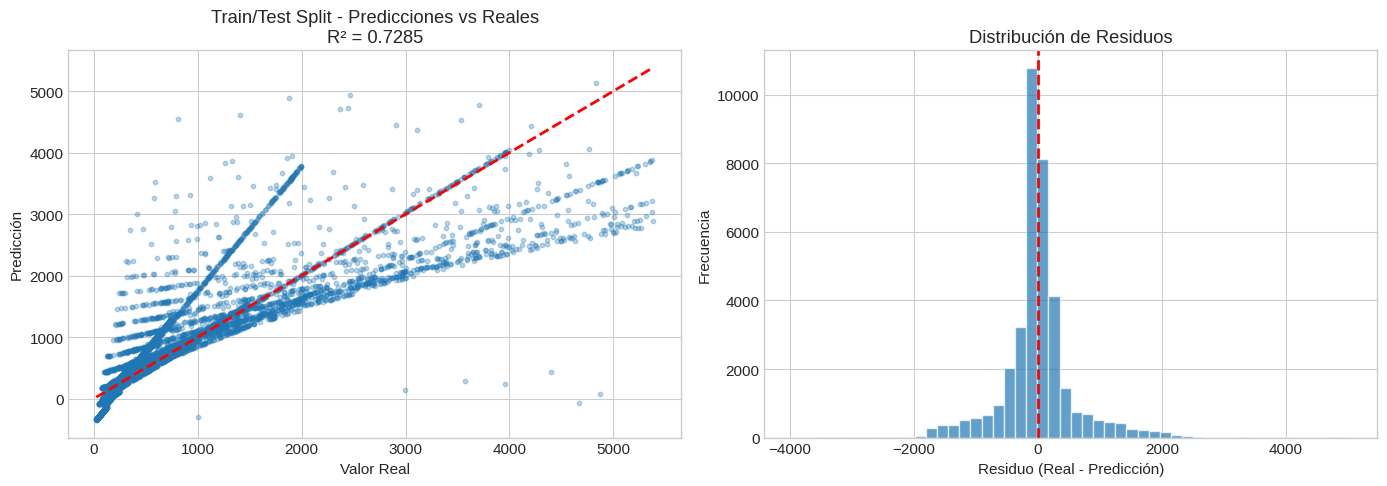

In [33]:
# Visualización: Predicciones vs Valores Reales
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
sample_idx = np.random.choice(len(y_test), min(5000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_pred_test[sample_idx], alpha=0.3, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Valor Real')
axes[0].set_ylabel('Predicción')
axes[0].set_title(f'Train/Test Split - Predicciones vs Reales\nR² = {r2_test:.4f}')

# Distribución de residuos
residuos = y_test.values - y_pred_test
axes[1].hist(residuos, bins=50, edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuo (Real - Predicción)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')

plt.tight_layout()
plt.show()

## Evaluación de la Calidad del Modelo Predictivo

Después de entrenar un modelo de Machine Learning, la pregunta más importante es: **¿Qué tan bien predice?** Para responder esto, analizamos dos gráficos complementarios.

---

## Gráfico 1: Valores Reales vs Predicciones

### ¿Qué estamos viendo?

Imagina que tienes 5,000 ventas de prueba. Para cada una:
- Ya conoces el **monto real** (lo que realmente se vendió)
- El modelo calculó una **predicción** (lo que él cree que se vendió)

Este gráfico pone un punto por cada venta: su valor real en el eje X, su predicción en el eje Y.

### ¿Cómo leerlo?
```
         Predicción
              │
        5000  │                    · · ·
              │                 · · ·
        4000  │              · · ·
              │           · · · ·
        3000  │        · · · · ╱
              │     · · · · ╱
        2000  │   · · · · ╱    ← Línea roja = predicción perfecta
              │  · · · ╱         (donde predicción = real)
        1000  │ · · ╱
              │· ╱
            0 └──────────────────────────
              0    1000   2000   3000   4000   5000
                              Valor Real
```

**La línea roja diagonal es la referencia de predicción perfecta.** Si el modelo fuera perfecto, todos los puntos estarían exactamente sobre esa línea.

| Si el punto está... | Significa que... | Ejemplo |
|---------------------|------------------|---------|
| **Sobre la línea** | Predicción = Real | Real: $1,000 → Predicción: $1,000 ✓ |
| **Debajo de la línea** | Predicción < Real (subestima) | Real: $3,000 → Predicción: $2,200 ↓ |
| **Arriba de la línea** | Predicción > Real (sobreestima) | Real: $500 → Predicción: $800 ↑ |

---

### ¿Qué nos dice el R² = 0.7285?

El **R² (coeficiente de determinación)** responde: *¿Qué porcentaje de la variabilidad en las ventas puede explicar el modelo?*
```
R² = 0.7285 significa:

    ┌────────────────────────────────────────────────────┐
    │██████████████████████████████████████████░░░░░░░░░░│
    │◄──────────── 72.85% ─────────────►│◄── 27.15% ──►│
    │     Explicado por el modelo       │  No explicado │
    └────────────────────────────────────────────────────┘
```

**Escala de interpretación del R²:**

| R² | Calidad | Interpretación práctica |
|----|---------|-------------------------|
| < 0.30 | Pobre | El modelo casi no captura patrones útiles |
| 0.30 - 0.50 | Débil | Captura tendencias básicas, pero falta mucho |
| 0.50 - 0.70 | Moderado | Útil, pero con margen de mejora significativo |
| **0.70 - 0.85** | **Bueno** | **Captura la mayoría de patrones (nuestro caso)** |
| > 0.85 | Excelente | Muy preciso (pero verificar overfitting) |

---

### Observaciones específicas de nuestra gráfica

**1. ¿Por qué se ven "líneas paralelas" en lugar de una nube de puntos?**

Esto es **normal y esperado**. Ocurre porque la variable `cantidad` es un número entero (1, 2, 3... unidades).
```
Recuerda que:  monto = precio × cantidad

Si cantidad = 1:  monto = precio × 1  → forma una línea
Si cantidad = 2:  monto = precio × 2  → forma otra línea paralela
Si cantidad = 3:  monto = precio × 3  → forma otra línea paralela
...y así sucesivamente
```

Cada "banda" que ves corresponde a un valor diferente de cantidad. **No es un error del modelo**, es la estructura natural de los datos.

**2. ¿Por qué los puntos se alejan de la línea roja en valores altos?**

Observa que para montos mayores a $3,000, los puntos tienden a quedar **debajo** de la línea roja. Esto significa que el modelo **subestima las ventas grandes**.
```
Ejemplo de lo que ocurre:

    Venta real: $5,000
    Predicción: $3,800  ← El modelo predijo menos
    
    Venta real: $4,500
    Predicción: $3,500  ← El modelo predijo menos
```

**¿Por qué pasa esto?** La regresión lineal asume relaciones "rectas", pero las ventas muy altas pueden tener comportamientos diferentes (clientes VIP, compras mayoristas, temporadas especiales) que el modelo lineal no captura completamente.

---

## Gráfico 2: Distribución de Residuos

### ¿Qué es un residuo?

El residuo es simplemente **el error de cada predicción**:
```
Residuo = Valor Real − Predicción

┌─────────────────────────────────────────────────────────────┐
│                                                             │
│   Si Real = $1,000 y Predicción = $1,000  →  Residuo = 0    │
│   Si Real = $1,000 y Predicción = $800   →  Residuo = +200  │
│   Si Real = $1,000 y Predicción = $1,300  →  Residuo = -300 │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

| Residuo | Significado |
|---------|-------------|
| = 0 | Predicción perfecta |
| > 0 (positivo) | El modelo **subestimó** (la realidad fue mayor) |
| < 0 (negativo) | El modelo **sobreestimó** (la realidad fue menor) |

---

### ¿Qué buscamos en el histograma?

El histograma muestra **cuántas predicciones tuvieron cada nivel de error**:
```
    Frecuencia
         │
   10000 │       █
         │       █
    8000 │       █
         │      ███
    6000 │      ███
         │     █████
    4000 │    ███████
         │   █████████
    2000 │  ███████████
         │████████████████
       0 └────────│────────────────
              -4000    0    +2000   +4000
                        │
                  Línea roja (cero)
                  
          ◄─────────┼──────────►
          Sobreestimó │ Subestimó
```

### ¿Qué características debe tener un buen modelo?

| Característica | ¿Qué indica? | ¿Nuestro modelo lo cumple? |
|----------------|--------------|----------------------------|
| **Centrado en cero** | No hay sesgo sistemático (no siempre sobreestima ni siempre subestima) |  Sí, el pico está en 0 |
| **Forma de campana simétrica** | Los errores son aleatorios, no hay un patrón predecible |  Sí, aproximadamente simétrico |
| **Pico alto y concentrado** | La mayoría de errores son pequeños |  Sí, la mayoría cerca de 0 |
| **Colas cortas** | Pocos errores extremadamente grandes | ⚠️ Parcial, hay errores hasta ±4,000 |

---

### Análisis de nuestro histograma

**Lo positivo:**

1. **Centrado en cero:** El modelo no tiene "preferencia" por sobreestimar o subestimar. En promedio, los errores se cancelan.

2. **Pico alto en el centro:** La mayoría de las predicciones tienen errores pequeños (cercanos a cero). Esto significa que para la mayoría de ventas, el modelo predice razonablemente bien.

3. **Forma aproximadamente normal:** La distribución tipo "campana" indica que los errores son aleatorios, no sistemáticos. Esto es deseable.

**Lo mejorable:**

4. **Colas extendidas:** Hay predicciones con errores de hasta $4,000. Estos corresponden a ventas atípicas donde el modelo falla significativamente.

---

## Diagnóstico Final: ¿Qué tan bueno es nuestro modelo?

| Aspecto evaluado | Resultado | Veredicto |
|------------------|-----------|-----------|
| **R² (capacidad predictiva)** | 0.7285 (73%) |  **Bueno** - Captura la mayoría de la variabilidad |
| **Sesgo** | Residuos centrados en 0 |  **Ninguno** - No sobreestima ni subestima sistemáticamente |
| **Distribución de errores** | Forma de campana |  **Normal** - Errores aleatorios, no sistemáticos |
| **Predicción de valores extremos** | Subestima montos >$3,000 |  **Mejorable** - Limitación del modelo lineal |

---

## Conclusión

El modelo de **Regresión Lineal** tiene un desempeño **bueno como punto de partida**:

 Explica el **73% de la variabilidad** en las ventas
 No tiene **sesgo sistemático**
 La **mayoría de predicciones** tienen errores pequeños

 **Limitación principal:** Dificultad para predecir ventas de montos muy altos

---

## ¿Qué sigue?

Este modelo sirve como **baseline** (línea base de comparación). En las siguientes etapas:

1. **Cross-Validation:** Verificaremos si el R² de 0.73 es estable o fue "suerte" de la partición de datos
2. **Modelos avanzados:** Probaremos algoritmos como Random Forest o XGBoost que capturan relaciones no lineales
3. **Feature engineering:** Crearemos nuevas variables que ayuden a predecir mejor los casos extremos

Un R² alto no garantiza un buen modelo. Siempre debemos verificar los residuos y validar con datos que el modelo nunca vio durante el entrenamiento.

### Problema del Train/Test Split: Variabilidad

Veamos cómo cambian los resultados con diferentes semillas aleatorias.

In [34]:
# Demostrar variabilidad del Train/Test Split
r2_scores_split = []
rmse_scores_split = []

print(' VARIABILIDAD DEL TRAIN/TEST SPLIT')
print('=' * 50)
print('Ejecutando 10 divisiones diferentes...\n')

for seed in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X_scaled, y, test_size=0.20, random_state=seed)
    modelo = LinearRegression()
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    r2_scores_split.append(r2)
    rmse_scores_split.append(rmse)

    print(f'  Seed {seed}: R² = {r2:.4f}, RMSE = {rmse:.2f}')

print('\n' + '=' * 50)
print(f' R² promedio: {np.mean(r2_scores_split):.4f} ± {np.std(r2_scores_split):.4f}')
print(f' RMSE promedio: {np.mean(rmse_scores_split):.2f} ± {np.std(rmse_scores_split):.2f}')
print(f'\n  Variación en R²: {np.max(r2_scores_split) - np.min(r2_scores_split):.4f}')

 VARIABILIDAD DEL TRAIN/TEST SPLIT
Ejecutando 10 divisiones diferentes...

  Seed 0: R² = 0.7307, RMSE = 591.17
  Seed 1: R² = 0.7297, RMSE = 585.24
  Seed 2: R² = 0.7318, RMSE = 583.68
  Seed 3: R² = 0.7265, RMSE = 591.60
  Seed 4: R² = 0.7226, RMSE = 594.44
  Seed 5: R² = 0.7282, RMSE = 588.96
  Seed 6: R² = 0.7309, RMSE = 588.03
  Seed 7: R² = 0.7277, RMSE = 588.42
  Seed 8: R² = 0.7290, RMSE = 588.00
  Seed 9: R² = 0.7318, RMSE = 583.38

 R² promedio: 0.7289 ± 0.0027
 RMSE promedio: 588.29 ± 3.35

  Variación en R²: 0.0093


---
## Parte 8: Método 2 - 5-Fold Cross-Validation

Dividimos los datos en 5 partes y entrenamos 5 veces, usando cada parte como prueba una vez.

In [35]:
# Configurar 5-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

print(' 5-FOLD CROSS-VALIDATION')
print('=' * 50)
print('\nEstructura de los folds:')

for i, (train_idx, test_idx) in enumerate(kfold.split(X_scaled)):
    print(f'  Fold {i+1}: Train = {len(train_idx):,} muestras, Test = {len(test_idx):,} muestras')

 5-FOLD CROSS-VALIDATION

Estructura de los folds:
  Fold 1: Train = 149,749 muestras, Test = 37,438 muestras
  Fold 2: Train = 149,749 muestras, Test = 37,438 muestras
  Fold 3: Train = 149,750 muestras, Test = 37,437 muestras
  Fold 4: Train = 149,750 muestras, Test = 37,437 muestras
  Fold 5: Train = 149,750 muestras, Test = 37,437 muestras


In [37]:
# Realizar Cross-Validation manual para ver detalle por fold
modelo_cv = LinearRegression()

r2_por_fold = []
rmse_por_fold = []
mae_por_fold = []

print('\n RESULTADOS POR FOLD')
print('=' * 50)

for i, (train_idx, test_idx) in enumerate(kfold.split(X_scaled)):
    # Dividir datos
    X_train_fold = X_scaled.iloc[train_idx]
    X_test_fold = X_scaled.iloc[test_idx]
    y_train_fold = y.iloc[train_idx]
    y_test_fold = y.iloc[test_idx]

    # Entrenar
    modelo_cv.fit(X_train_fold, y_train_fold)

    # Predecir y evaluar
    y_pred_fold = modelo_cv.predict(X_test_fold)

    r2 = r2_score(y_test_fold, y_pred_fold)
    rmse = np.sqrt(mean_squared_error(y_test_fold, y_pred_fold))
    mae = mean_absolute_error(y_test_fold, y_pred_fold)

    r2_por_fold.append(r2)
    rmse_por_fold.append(rmse)
    mae_por_fold.append(mae)

    print(f'  Fold {i+1}: R² = {r2:.4f}, RMSE = {rmse:.2f}, MAE = {mae:.2f}')

print('\n' + '=' * 50)
print(' RESULTADOS CONSOLIDADOS (5-Fold CV)')
print('=' * 50)
print(f'  R² Score:  {np.mean(r2_por_fold):.4f} ± {np.std(r2_por_fold):.4f}')
print(f'  RMSE:      {np.mean(rmse_por_fold):.2f} ± {np.std(rmse_por_fold):.2f}')
print(f'  MAE:       {np.mean(mae_por_fold):.2f} ± {np.std(mae_por_fold):.2f}')


 RESULTADOS POR FOLD
  Fold 1: R² = 0.7285, RMSE = 591.78, MAE = 366.19
  Fold 2: R² = 0.7310, RMSE = 583.04, MAE = 359.94
  Fold 3: R² = 0.7269, RMSE = 591.11, MAE = 365.19
  Fold 4: R² = 0.7372, RMSE = 576.71, MAE = 359.74
  Fold 5: R² = 0.7273, RMSE = 592.13, MAE = 365.70

 RESULTADOS CONSOLIDADOS (5-Fold CV)
  R² Score:  0.7302 ± 0.0038
  RMSE:      586.95 ± 6.13
  MAE:       363.35 ± 2.88


In [38]:
# Guardar resultados para comparación
resultados_cv = {
    'metodo': '5-Fold Cross-Validation',
    'r2': np.mean(r2_por_fold),
    'r2_std': np.std(r2_por_fold),
    'rmse': np.mean(rmse_por_fold),
    'rmse_std': np.std(rmse_por_fold),
    'mae': np.mean(mae_por_fold)
}

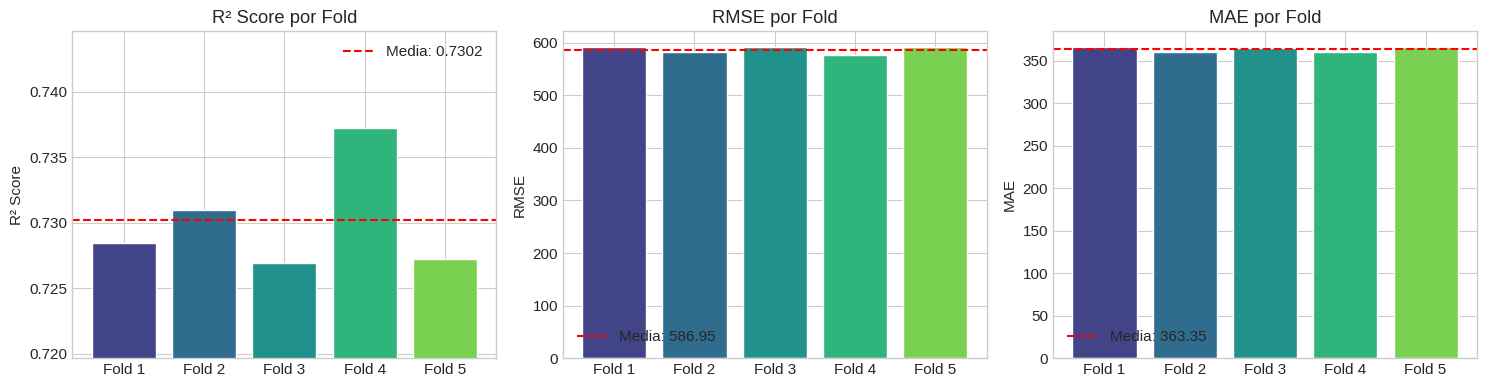

In [39]:
# Visualización de resultados por Fold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, 5))

# R² por fold
bars1 = axes[0].bar(folds, r2_por_fold, color=colors, edgecolor='white')
axes[0].axhline(y=np.mean(r2_por_fold), color='red', linestyle='--', label=f'Media: {np.mean(r2_por_fold):.4f}')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score por Fold')
axes[0].legend()
axes[0].set_ylim([min(r2_por_fold)*0.99, max(r2_por_fold)*1.01])

# RMSE por fold
bars2 = axes[1].bar(folds, rmse_por_fold, color=colors, edgecolor='white')
axes[1].axhline(y=np.mean(rmse_por_fold), color='red', linestyle='--', label=f'Media: {np.mean(rmse_por_fold):.2f}')
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE por Fold')
axes[1].legend()

# MAE por fold
bars3 = axes[2].bar(folds, mae_por_fold, color=colors, edgecolor='white')
axes[2].axhline(y=np.mean(mae_por_fold), color='red', linestyle='--', label=f'Media: {np.mean(mae_por_fold):.2f}')
axes[2].set_ylabel('MAE')
axes[2].set_title('MAE por Fold')
axes[2].legend()

plt.tight_layout()
plt.show()

##  Visualización: Métricas por Fold

### ¿Qué muestran estos gráficos?

Tres gráficos de barras comparando el rendimiento del modelo en cada uno de los 5 folds:
```
┌─────────────────┬─────────────────┬─────────────────┐
│   R² por Fold   │  RMSE por Fold  │  MAE por Fold   │
│                 │                 │                 │
│  █ █ █ █ █      │  █ █ █ █ █      │  █ █ █ █ █      │
│  ─────── media  │  ─────── media  │  ─────── media  │
│                 │                 │                 │
└─────────────────┴─────────────────┴─────────────────┘
```

### ¿Cómo interpretarlos?

| Observación | Indica |
|-------------|--------|
| Barras de altura similar | Modelo **estable** |
| Barras muy diferentes | Modelo **inestable**  |
| Línea roja | Promedio de los 5 folds |

### Las 3 métricas

| Métrica | Qué mide | ¿Qué queremos? |
|---------|----------|----------------|
| **R²** | Varianza explicada | Alto y uniforme |
| **RMSE** | Error (penaliza grandes) | Bajo |
| **MAE** | Error absoluto promedio | Bajo |

> Si las barras tienen alturas similares, el modelo es **consistente** independientemente de qué datos use para entrenar.

---
## Parte 9: Comparación de Métodos

In [40]:
# Tabla comparativa
print('\n' + '=' * 70)
print(' COMPARACIÓN: TRAIN/TEST SPLIT vs 5-FOLD CROSS-VALIDATION')
print('=' * 70)
print(f'{"Métrica":<20} {"Train/Test Split":<25} {"5-Fold CV":<25}')
print('-' * 70)
print(f'{"R² Score":<20} {resultados_split["r2"]:.4f}{"":<20} {resultados_cv["r2"]:.4f} ± {resultados_cv["r2_std"]:.4f}')
print(f'{"RMSE":<20} {resultados_split["rmse"]:.2f}{"":<22} {resultados_cv["rmse"]:.2f} ± {resultados_cv["rmse_std"]:.2f}')
print(f'{"MAE":<20} {resultados_split["mae"]:.2f}{"":<22} {resultados_cv["mae"]:.2f}')
print('-' * 70)
print(f'{"Datos usados":<20} {"80% train, 20% test":<25} {"100% (rotando)":<25}')
print(f'{"Modelos entrenados":<20} {"1":<25} {"5":<25}')
print(f'{"Variabilidad":<20} {"Alta (depende del split)":<25} {"Baja (promedio de 5)":<25}')
print('=' * 70)


 COMPARACIÓN: TRAIN/TEST SPLIT vs 5-FOLD CROSS-VALIDATION
Métrica              Train/Test Split          5-Fold CV                
----------------------------------------------------------------------
R² Score             0.7285                     0.7302 ± 0.0038
RMSE                 591.78                       586.95 ± 6.13
MAE                  366.19                       363.35
----------------------------------------------------------------------
Datos usados         80% train, 20% test       100% (rotando)           
Modelos entrenados   1                         5                        
Variabilidad         Alta (depende del split)  Baja (promedio de 5)     


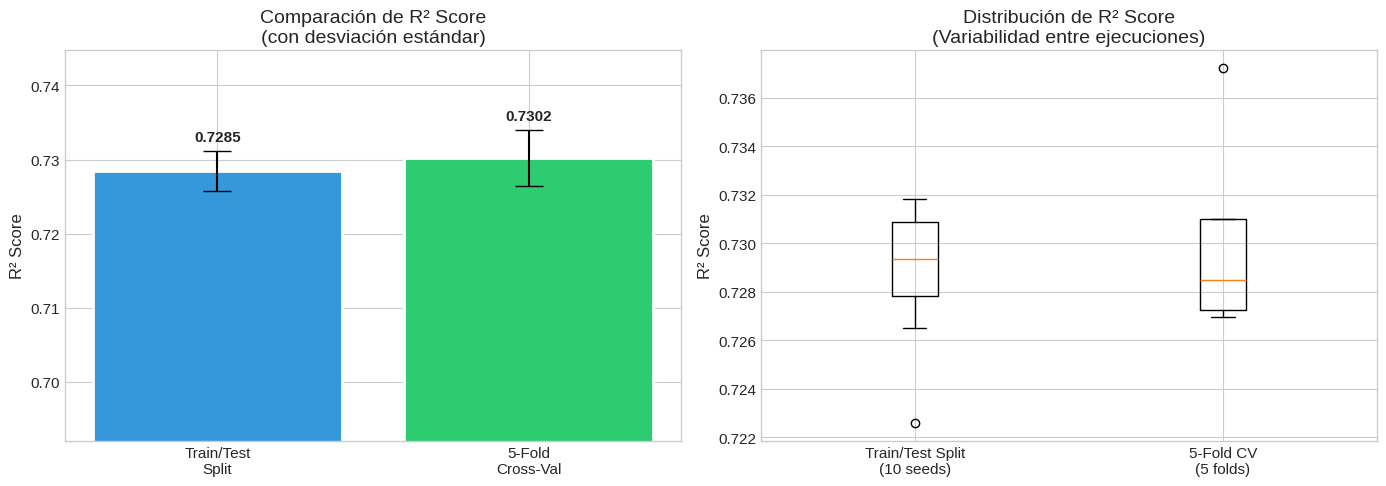

In [41]:
# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Comparación de R²
metodos = ['Train/Test\nSplit', '5-Fold\nCross-Val']
r2_values = [resultados_split['r2'], resultados_cv['r2']]
r2_errors = [np.std(r2_scores_split), resultados_cv['r2_std']]

bars = axes[0].bar(metodos, r2_values, yerr=r2_errors, capsize=10,
                   color=['#3498db', '#2ecc71'], edgecolor='white', linewidth=2)
axes[0].set_ylabel('R² Score', fontsize=12)
axes[0].set_title('Comparación de R² Score\n(con desviación estándar)', fontsize=14)
axes[0].set_ylim([min(r2_values)*0.95, max(r2_values)*1.02])

for bar, val, err in zip(bars, r2_values, r2_errors):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + err + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Gráfico 2: Variabilidad del Train/Test Split vs CV
axes[1].boxplot([r2_scores_split, r2_por_fold], labels=['Train/Test Split\n(10 seeds)', '5-Fold CV\n(5 folds)'])
axes[1].set_ylabel('R² Score', fontsize=12)
axes[1].set_title('Distribución de R² Score\n(Variabilidad entre ejecuciones)', fontsize=14)

plt.tight_layout()
plt.show()

---
## Parte 11: Experimento Extra - Diferentes Valores de K

In [ ]:
# Comparar diferentes valores de K en Cross-Validation
k_values = [3, 5, 10]
resultados_k = []

print(' EFECTO DEL NÚMERO DE FOLDS (K)')
print('=' * 60)

for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    # Cross-validation con sklearn
    scores = cross_val_score(LinearRegression(), X_scaled, y, cv=kf, scoring='r2')

    resultados_k.append({
        'k': k,
        'r2_mean': scores.mean(),
        'r2_std': scores.std()
    })

    print(f'  {k}-Fold CV: R² = {scores.mean():.4f} ± {scores.std():.4f}')

print('\n A mayor K, más datos de entrenamiento por fold,')
print('   pero también más tiempo de cómputo.')

In [ ]:
# Visualización del efecto de K
fig, ax = plt.subplots(figsize=(10, 5))

k_vals = [r['k'] for r in resultados_k]
r2_means = [r['r2_mean'] for r in resultados_k]
r2_stds = [r['r2_std'] for r in resultados_k]

ax.bar(range(len(k_vals)), r2_means, yerr=r2_stds, capsize=10,
       color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='white', linewidth=2)
ax.set_xticks(range(len(k_vals)))
ax.set_xticklabels([f'{k}-Fold' for k in k_vals])
ax.set_ylabel('R² Score')
ax.set_title('Efecto del número de Folds (K) en Cross-Validation')
ax.set_ylim([min(r2_means)*0.99, max(r2_means)*1.01])

for i, (mean, std) in enumerate(zip(r2_means, r2_stds)):
    ax.text(i, mean + std + 0.001, f'{mean:.4f}\n±{std:.4f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

---
### que hay pa hacer:

1. Experimentar cambiando el porcentaje de test (10%, 20%, 30%) y observar cómo afecta los resultados
2. Probar con diferentes valores de K (3, 5, 10, 20) y documentar las diferencias
3. Aplicar ambos métodos a un modelo diferente (ej: Random Forest) y comparar

---


---

##Conexión entre Modelos: De Regresión a Clasificación

### El Camino de Aprendizaje
```
(Hoy)              
REGRESIÓN                  CLASIFICACIÓN              ENSEMBLE
   │                            │                         │
   ▼                            ▼                         ▼
Regresión Lineal ────────► Regresión Logística      Random Forest
(predice números)          (predice Sí/No)          XGBoost
       │                            │                    ▲
       │                            ▼                    │
       │                     Árbol de Decisión ──────────┘
       │                     (predice categorías)   (muchos árboles
       │                                             combinados)
       │                            
       └──────────────────► Random Forest Regressor
                          


